<a href="https://colab.research.google.com/github/ZidAvwa/PCVK_Ganjil_2026/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== IDENTITY CELL - DO NOT DELETE, MUST BE THE FIRST CELL =====
import sys, platform, hashlib, datetime, zoneinfo

NAME = "Zid'Avwa Al Bari'i"
STUDENT_ID = '244107020083'          # replace with your student ID

N     = int(STUDENT_ID[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
now = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAME   :', NAME)
print('ID     :', STUDENT_ID, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('TIME   :', now.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SYSTEM :', sys.version.split()[0], platform.platform())
key_str = STUDENT_ID + '|' + now.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(key_str.encode()).hexdigest()[:16])

NAME   : Zid'Avwa Al Bari'i
ID     : 244107020083 | N = 83
bins   : 64
clip   : 2.5
tile   : 5
L      : 8
TIME   : 2026-09-30 19:50:46 WIB
SYSTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 163b20af0195f277


**Part 0 - Setup + Drive**

---

In [2]:
from google.colab import drive
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
import math
import os
import glob

drive.mount('/content/drive')

SAMPLES = '/content/drive/MyDrive/PCVK Semester 5/Images'
BASE    = '/content/drive/MyDrive/PCVK Semester 5/' + STUDENT_ID

Mounted at /content/drive


In [3]:
def read_image(path, flag=cv.IMREAD_COLOR):
    img = cv.imread(path, flag)
    if img is None:
        raise FileNotFoundError('Image not found: ' + path)
    return img

def make_title(t):
    return STUDENT_ID + ' - ' + t

def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    return 20 * math.log10(255.0 / math.sqrt(mse))

print('BASE  :', BASE)
print('KTM files found:', sorted(os.path.basename(f) for f in glob.glob(BASE + '/KTM1*.jpg')))

BASE  : /content/drive/MyDrive/PCVK Semester 5/244107020083
KTM files found: ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']


**Part 1 - E-1 Histogram (manual)**

---

In [4]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for v in img.ravel().tolist():
        h[v] += 1
    return h

def plot_hist_rgb(img_bgr, t):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(make_title(t))
    for ax, (name, color, idx) in zip(axs, [('Red', 'red', 2), ('Green', 'green', 1), ('Blue', 'blue', 0)]):
        h = histogram_manual(img_bgr[:, :, idx])
        assert h.sum() == img_bgr.shape[0] * img_bgr.shape[1]
        ax.bar(np.arange(256), h, color=color)
        ax.set_title(name)
    fig.text(0.09, 0.5, 'Number of Occurrences', va='center', rotation='vertical')
    fig.text(0.5, 0.02, 'Color Intensity', ha='center')
    plt.show()

**Stage 1 - sample image (lena.jpg)**

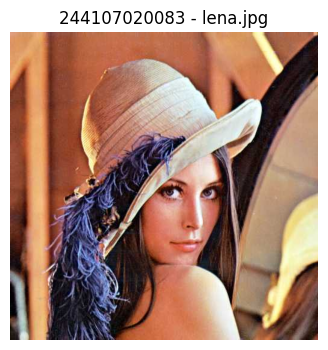

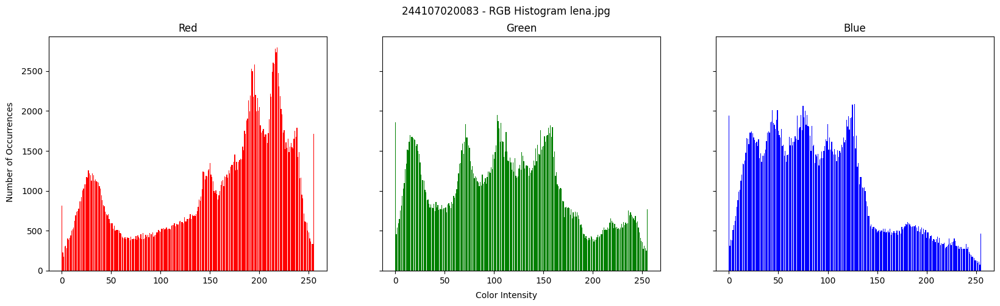

In [5]:
lena = read_image(SAMPLES + '/lena.jpg')

plt.figure(figsize=(4, 4))
plt.imshow(cv.cvtColor(lena, cv.COLOR_BGR2RGB))
plt.title(make_title('lena.jpg'))
plt.axis('off')
plt.show()

plot_hist_rgb(lena, 'RGB Histogram lena.jpg')

**Stage 2 - own image (KTM1b.jpg)**

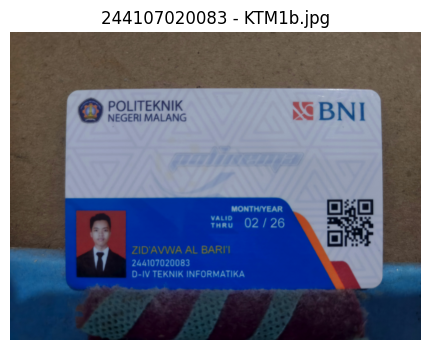

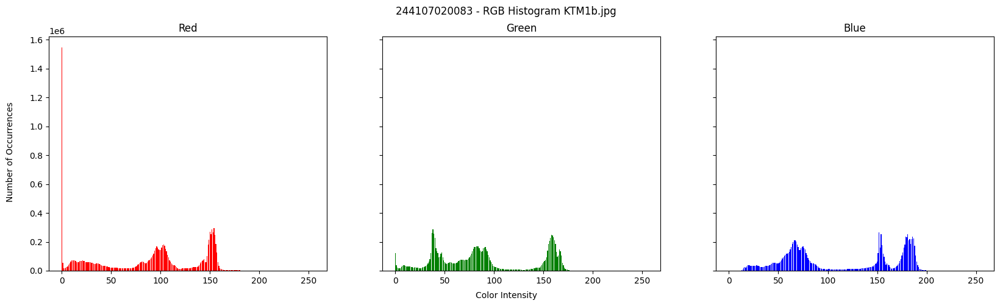

In [6]:
ktm1b = read_image(BASE + '/KTM1b.jpg')

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB))
plt.title(make_title('KTM1b.jpg'))
plt.axis('off')
plt.show()

plot_hist_rgb(ktm1b, 'RGB Histogram KTM1b.jpg')

**Part 2 - E-1 Question 1 (manual vs np.histogram vs cv.calcHist)**

---

In [7]:
def compare_hist(img_bgr, name):
    print('=== %s ===' % name)
    channels = {'Gray': cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY),
                'B': img_bgr[:, :, 0], 'G': img_bgr[:, :, 1], 'R': img_bgr[:, :, 2]}
    for k, c in channels.items():
        h_man = histogram_manual(c)
        h_np  = np.histogram(c, bins=256, range=(0, 256))[0]
        h_cv  = cv.calcHist([c], [0], None, [256], [0, 256]).ravel().astype(np.int64)
        d1 = np.abs(h_man - h_np).max()
        d2 = np.abs(h_man - h_cv).max()
        d3 = np.abs(h_np - h_cv).max()
        print('%-5s max difference | manual-numpy: %d | manual-calcHist: %d | numpy-calcHist: %d' % (k, d1, d2, d3))
        assert d1 == 0 and d2 == 0 and d3 == 0

compare_hist(lena, 'lena.jpg (stage 1)')
compare_hist(ktm1b, 'KTM1b.jpg (stage 2)')

=== lena.jpg (stage 1) ===
Gray  max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
B     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
G     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
R     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
=== KTM1b.jpg (stage 2) ===
Gray  max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
B     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
G     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
R     max difference | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0


**Answer E1-1**

The three methods (manual loop, `np.histogram`, `cv.calcHist`) produce exactly identical histograms, as shown by a maximum difference of 0 in all channels, for both lena.jpg and KTM1b.jpg.

**Part 3 - E-1 Question 2 (p(j) and CDF of KTM1a - KTM1d)**

---

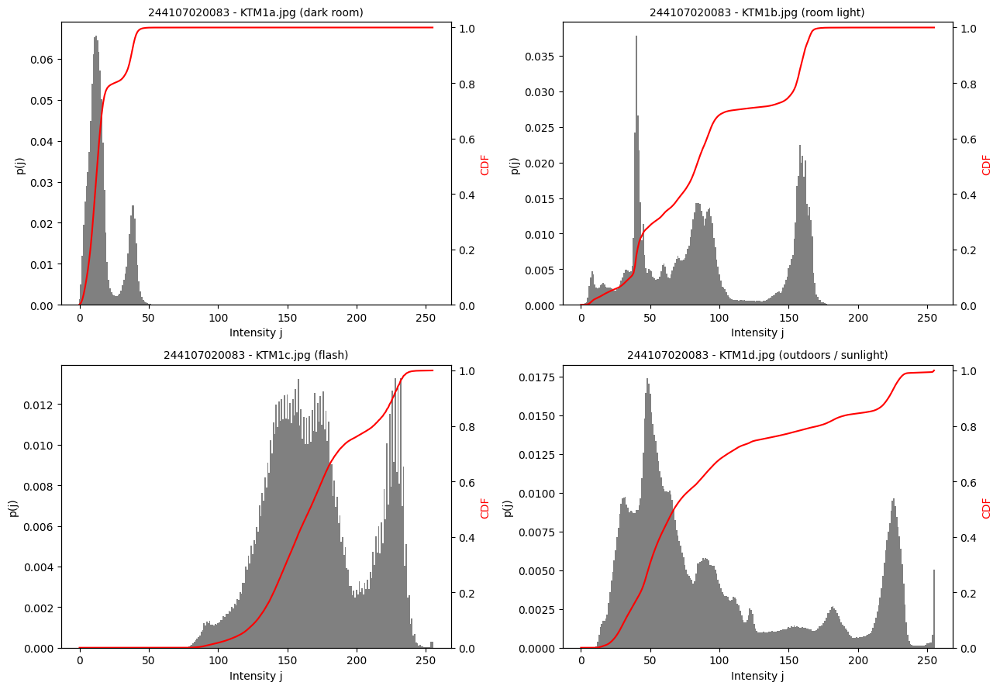

     file  mean  median (CDF=0.5)  pixels < 64 (%)  pixels > 192 (%)
KTM1a.jpg  16.7                13            100.0              -0.0
KTM1b.jpg  90.4                84             34.3               0.0
KTM1c.jpg 171.2               167              0.0              26.3
KTM1d.jpg  96.3                68             46.0              16.1

Darkest image  : KTM1a.jpg
Brightest image : KTM1c.jpg


In [8]:
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
conditions = ['dark room', 'room light', 'flash', 'outdoors / sunlight']

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
summary = []
for ax, f, k in zip(axs.flat, files, conditions):
    g = cv.cvtColor(read_image(BASE + '/' + f), cv.COLOR_BGR2GRAY)
    p = histogram_manual(g) / g.size
    cdf = np.cumsum(p)

    ax.bar(np.arange(256), p, color='gray', width=1.0)
    ax.set_xlabel('Intensity j')
    ax.set_ylabel('p(j)')
    ax2 = ax.twinx()
    ax2.plot(np.arange(256), cdf, color='red')
    ax2.set_ylim(0, 1.02)
    ax2.set_ylabel('CDF', color='red')
    ax.set_title(make_title(f + ' (' + k + ')'), fontsize=10)

    summary.append({'file': f,
                    'mean': round(float(g.mean()), 1),
                    'median (CDF=0.5)': int(np.searchsorted(cdf, 0.5)),
                    'pixels < 64 (%)': round(float(cdf[63]) * 100, 1),
                    'pixels > 192 (%)': round(float(1 - cdf[192]) * 100, 1)})
plt.tight_layout()
plt.show()

df_e1 = pd.DataFrame(summary)
print(df_e1.to_string(index=False))
print('\nDarkest image  :', df_e1.loc[df_e1['mean'].idxmin(), 'file'])
print('Brightest image :', df_e1.loc[df_e1['mean'].idxmax(), 'file'])

**Answer E1-2**

*Relation to lighting conditions at acquisition.*

- KTM1a: the photo was taken in a dark room, so little light reached the sensor (underexposed) and all pixels, including the card background and text, fall at low intensity. Details and text are hard to distinguish from the background, and dark noise is also visible.
- KTM1c: the flash adds a lot of direct light onto the card surface. Shadows are lifted (no pixels below about 80) and the whole histogram shifts to the right. The peak around 230 likely comes from areas of the card that reflect the flash (glossy surface or white areas). This photo is bright, but its contrast is narrower and it risks glare if the flash is too close.

*Comparison.*

- KTM1b (room light): the distribution is in the middle (about 0–180) and multimodal.
- KTM1d (sunlight): the distribution is the widest and its CDF rises gradually. There is a spike at 255 indicating saturated pixels caused by the strong sunlight.

**Part 4 - E-1 Question 3 (number of bins PARAM['bins'] vs 256)**

---

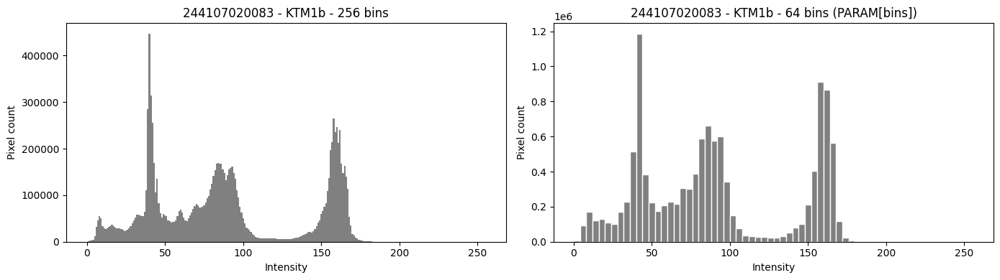

Each bin in the 64-bin histogram represents 4 intensity levels.
Total pixel count is the same: 11808768


In [9]:
g1b = cv.cvtColor(ktm1b, cv.COLOR_BGR2GRAY)
B = PARAM['bins']

h256, _ = np.histogram(g1b, bins=256, range=(0, 256))
hB, _   = np.histogram(g1b, bins=B,   range=(0, 256))
bin_width = 256 / B

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
axs[0].bar(np.arange(256), h256, color='gray', width=1.0)
axs[0].set_title(make_title('KTM1b - 256 bins'))
axs[1].bar(np.arange(B) * bin_width, hB, width=bin_width, align='edge', color='gray', edgecolor='white')
axs[1].set_title(make_title('KTM1b - %d bins (PARAM[bins])' % B))
for ax in axs:
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Pixel count')
plt.tight_layout()
plt.show()

assert h256.sum() == hB.sum() == g1b.size
print('Each bin in the %d-bin histogram represents %g intensity levels.' % (B, bin_width))
print('Total pixel count is the same: %d' % hB.sum())

**Answer E1-3**

- What stays the same: the total pixel count remains the same and the general shape of the distribution is also the same, namely three groups around 40, 85-90, and 160, with no pixels above about 185. The conclusion about lighting does not change.
- What changes: with 64 bins, each bar merges 4 consecutive levels (256/64 = 4), so the y-axis is higher (peak about 1.2 × 10⁶ vs 4.5 × 10⁵).
- Information lost:
  - The exact position of the narrow peak (level about 40) can no longer be read, because it is only known to lie within a range of 4 levels.
  - Fine details such as the double peak around 160 and the jaggedness around 85-90 merge into smoother bars.
  - Small bumps (around level 8 and 55-60) and empty levels become obscured.
- Impact: the histogram becomes more compact but its intensity resolution drops. For equalization and the CDF, 256 bins are still used, because the mapping is computed per intensity level.

**Part 5 - E-2 Histogram Equalization (manual)**

---

In [10]:
nk = np.array([790, 1023, 850, 656, 329, 245, 122, 81])
MN = nk.sum()
cdf3 = np.cumsum(nk) / MN
sk = 7 * cdf3
print('MN      :', MN)
print('p(rk)   :', np.round(nk / MN, 2))
print('CDF     :', np.round(cdf3, 2))
print('sk      :', np.round(sk, 2))
print('rounded :', np.round(sk).astype(int))
assert list(np.round(sk).astype(int)) == [1, 3, 5, 6, 6, 7, 7, 7]
print('Matches the module table.')

MN      : 4096
p(rk)   : [0.19 0.25 0.21 0.16 0.08 0.06 0.03 0.02]
CDF     : [0.19 0.44 0.65 0.81 0.89 0.95 0.98 1.  ]
sk      : [1.35 3.1  4.55 5.67 6.23 6.65 6.86 7.  ]
rounded : [1 3 5 6 6 7 7 7]
Matches the module table.


In [11]:
def he_manual(ch, L=256):
    h = np.bincount(ch.ravel(), minlength=L)
    cdf = np.cumsum(h) / ch.size
    lut = np.round(cdf * (L - 1)).astype(np.uint8)
    return lut[ch]

def he_color_manual(bgr):
    return cv.merge([he_manual(c) for c in cv.split(bgr)])

def show_he(bgr, name):
    he = he_color_manual(bgr)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title(make_title(name + ' (before)'))
    axs[1].imshow(cv.cvtColor(he, cv.COLOR_BGR2RGB))
    axs[1].set_title(make_title(name + ' (after manual HE)'))
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(2, 3, figsize=(20, 8), sharex=True)
    fig.suptitle(make_title('RGB Histogram ' + name + ' (top: before, bottom: after)'))
    for j, (color, idx) in enumerate([('red', 2), ('green', 1), ('blue', 0)]):
        axs[0, j].bar(np.arange(256), np.bincount(bgr[:, :, idx].ravel(), minlength=256), color=color)
        axs[1, j].bar(np.arange(256), np.bincount(he[:, :, idx].ravel(), minlength=256), color=color)
    fig.text(0.09, 0.5, 'Number of Occurrences', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Color Intensity', ha='center')
    plt.show()
    return he

**Stage 1 - sample image (lena_lc.jpg)**

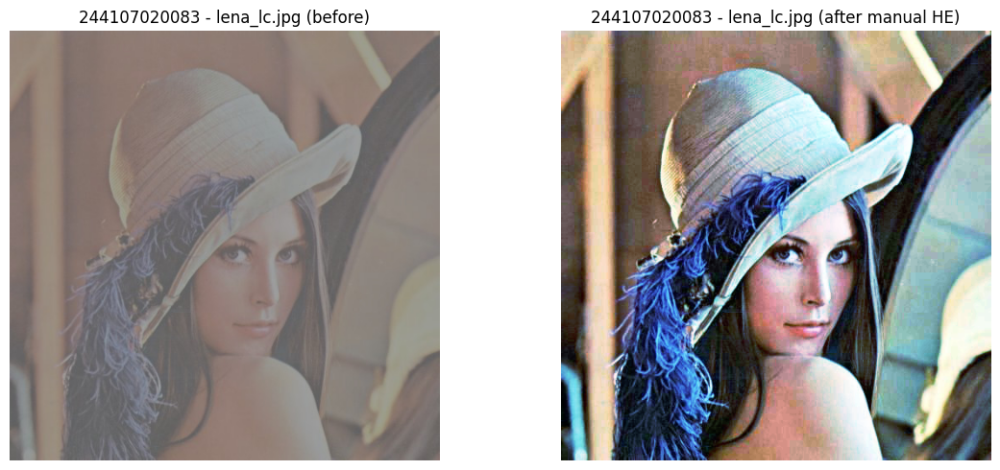

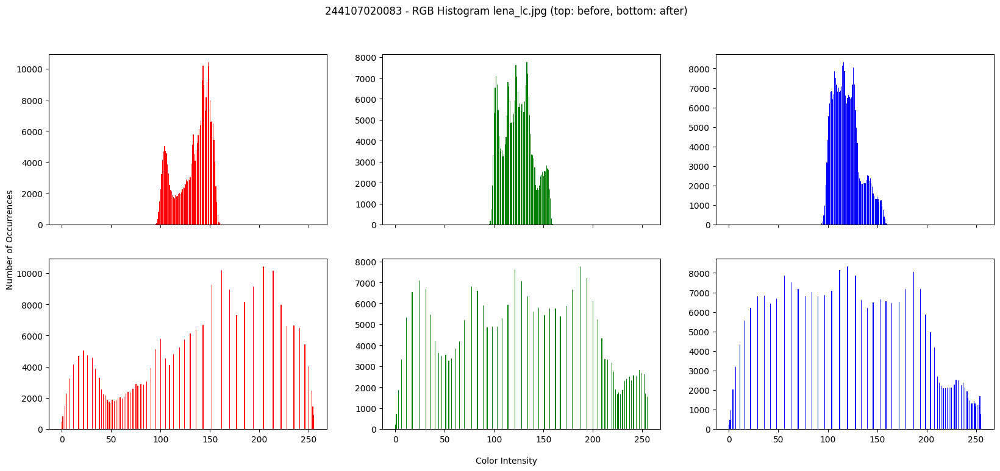

In [12]:
lena_lc = read_image(SAMPLES + '/lena_lc.jpg')
he_lena_lc = show_he(lena_lc, 'lena_lc.jpg')

**Stage 2 - own image (KTM1a.jpg, dark room)**

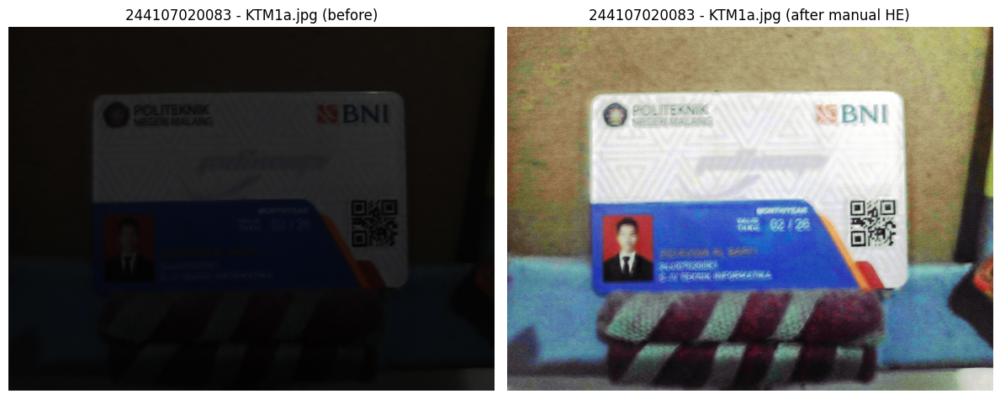

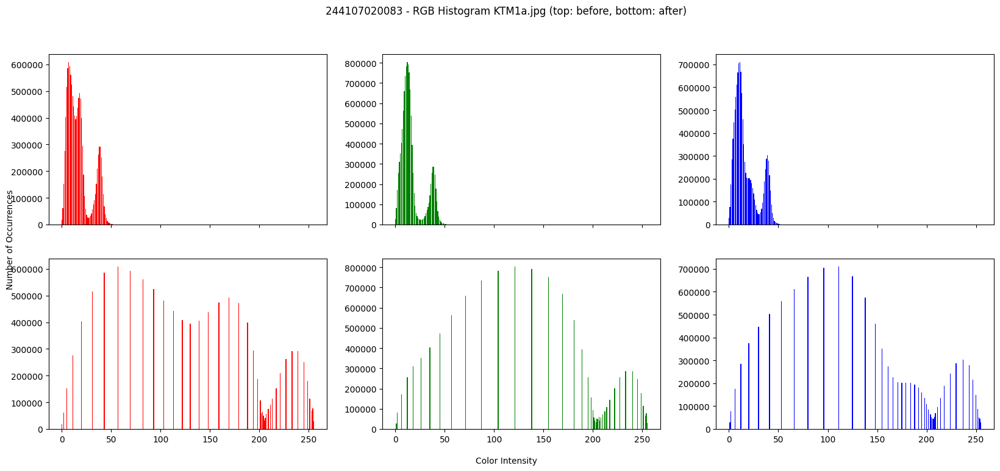

In [13]:
ktm1a = read_image(BASE + '/KTM1a.jpg')
he_ktm1a = show_he(ktm1a, 'KTM1a.jpg')

**Part 6 - E-2 step 2 (manual vs cv.equalizeHist)**

---

=== lena_lc.jpg (stage 1) ===
B | max difference module formula vs equalizeHist:   0 (mean 0.00) | cdf_min variant vs equalizeHist: 0
G | max difference module formula vs equalizeHist:   0 (mean 0.00) | cdf_min variant vs equalizeHist: 0
R | max difference module formula vs equalizeHist:   0 (mean 0.00) | cdf_min variant vs equalizeHist: 0
Gray | max difference module formula vs equalizeHist:   0 (mean 0.00)
=== KTM1a.jpg (stage 2) ===
B | max difference module formula vs equalizeHist:   1 (mean 0.33) | cdf_min variant vs equalizeHist: 0
G | max difference module formula vs equalizeHist:   1 (mean 0.30) | cdf_min variant vs equalizeHist: 0
R | max difference module formula vs equalizeHist:   1 (mean 0.26) | cdf_min variant vs equalizeHist: 0
Gray | max difference module formula vs equalizeHist:   1 (mean 0.24)


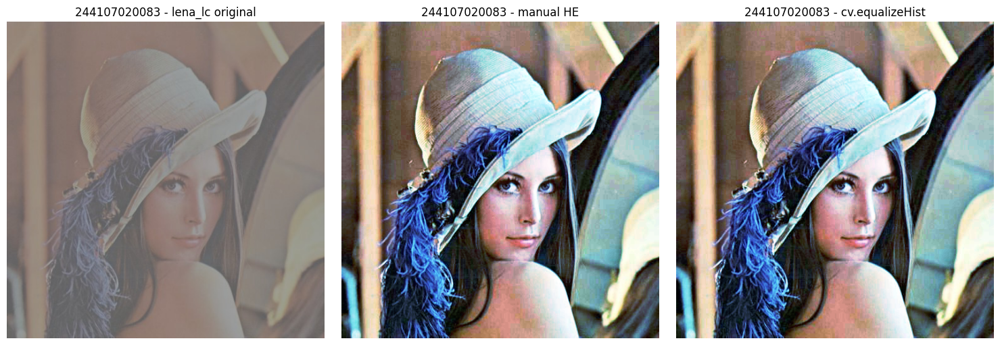

In [14]:
def he_manual_cdfmin(ch, L=256):
    cdf = np.cumsum(np.bincount(ch.ravel(), minlength=L))
    cmin = cdf[cdf > 0][0]
    lut = np.round((cdf - cmin) * (L - 1) / (ch.size - cmin)).clip(0, L - 1).astype(np.uint8)
    return lut[ch]

def compare_he(bgr, name):
    print('=== %s ===' % name)
    for k, c in zip(['B', 'G', 'R'], cv.split(bgr)):
        d_formula = np.abs(he_manual(c).astype(int) - cv.equalizeHist(c).astype(int))
        d_cdfmin  = np.abs(he_manual_cdfmin(c).astype(int) - cv.equalizeHist(c).astype(int))
        print('%s | max difference module formula vs equalizeHist: %3d (mean %.2f) | cdf_min variant vs equalizeHist: %d'
              % (k, d_formula.max(), d_formula.mean(), d_cdfmin.max()))
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    d = np.abs(he_manual(g).astype(int) - cv.equalizeHist(g).astype(int))
    print('Gray | max difference module formula vs equalizeHist: %3d (mean %.2f)' % (d.max(), d.mean()))

compare_he(lena_lc, 'lena_lc.jpg (stage 1)')
compare_he(ktm1a, 'KTM1a.jpg (stage 2)')

b, g, r = cv.split(lena_lc)
he_cv = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, t in zip(axs, [lena_lc, he_lena_lc, he_cv], ['lena_lc original', 'manual HE', 'cv.equalizeHist']):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(make_title(t))
    ax.axis('off')
plt.tight_layout()
plt.show()

**Answer E2 step 2**

- lena_lc.jpg: the difference is 0 in all channels. The lowest level that appears belongs to only a handful of pixels, so cdf_min / N is almost zero and the module formula gives the same result as cv.equalizeHist.
- KTM1a.jpg: the maximum difference is 1 level (mean about 0.3, meaning about a third of the pixels differ by 1 level). This image is dark, so quite a few pixels pile up at the lowest level and cdf_min can no longer be ignored.

**Part 7 - E-2 steps 3 & 4 (color image equalization + Hue shift)**

---

In [15]:
def hue_shift(original, result):
    h1 = cv.cvtColor(original, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(result,   cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)          # Hue is circular 0-179
    return d.mean()

def analyze_equalization(bgr, name):
    clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

    # method 1: equalize each channel separately
    channels = list(cv.split(bgr))
    for i in range(3):
        channels[i] = cv.equalizeHist(channels[i])
    he_rgb = cv.merge(channels)

    # method 2: equalize only the brightness channel
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, bb = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, bb]), cv.COLOR_LAB2BGR)

    # step 4: CLAHE on the brightness channel (Y)
    cl_y = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    titles_c = ['Original', 'B, G, R equalization', 'Y channel', 'V channel', 'L channel',
                'CLAHE on Y channel (clip %s, tile %d)' % (PARAM['clip'], PARAM['tile'])]
    images_c = [bgr, he_rgb, he_y, he_v, he_l, cl_y]

    fig, axs = plt.subplots(2, 3, figsize=(16, 9))
    for ax, c, t in zip(axs.flat, images_c, titles_c):
        ax.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        ax.set_title(make_title(name + ' - ' + t), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    rows = []
    for t, c in zip(titles_c, images_c):
        rows.append({'Equalization method': t,
                     'Mean Hue shift (degrees)': '-' if c is bgr else round(hue_shift(bgr, c) * 2, 2),
                     'Mean brightness after': round(float(cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()), 1),
                     'Visual observation notes': ''})
    return pd.DataFrame(rows)

**Stage 1 - sample image (lena.jpg)**

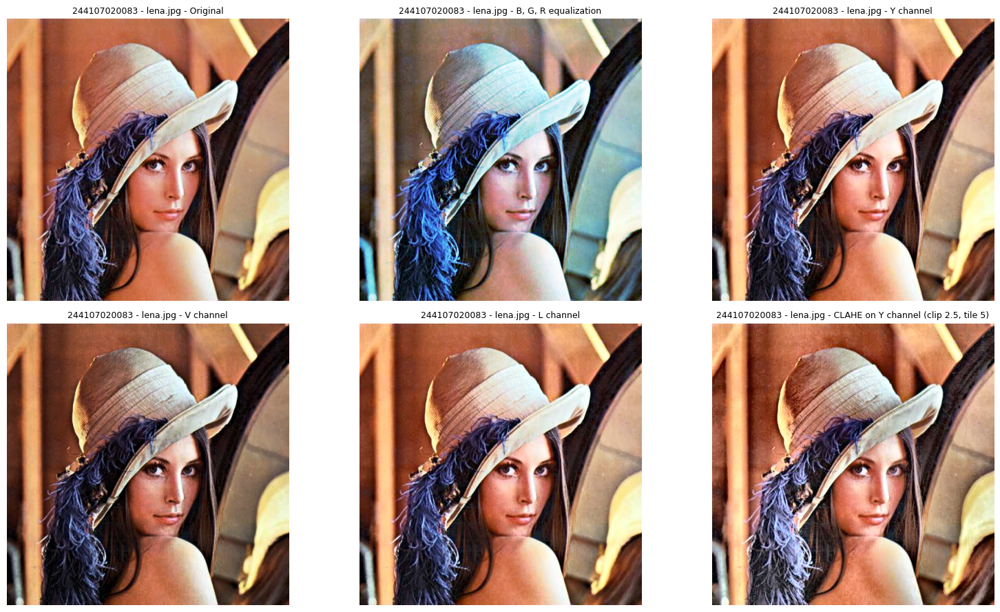

                  Equalization method Mean Hue shift (degrees)  Mean brightness after
                             Original                        -                  122.2
                 B, G, R equalization                    53.03                  127.4
                            Y channel                      0.4                  127.9
                            V channel                     0.87                  100.6
                            L channel                     1.65                  122.7
CLAHE on Y channel (clip 2.5, tile 5)                      0.5                  129.4


In [16]:
df_lena = analyze_equalization(lena, 'lena.jpg')
print(df_lena.drop(columns='Visual observation notes').to_string(index=False))

**Stage 2 - own image (KTM1d.jpg)**

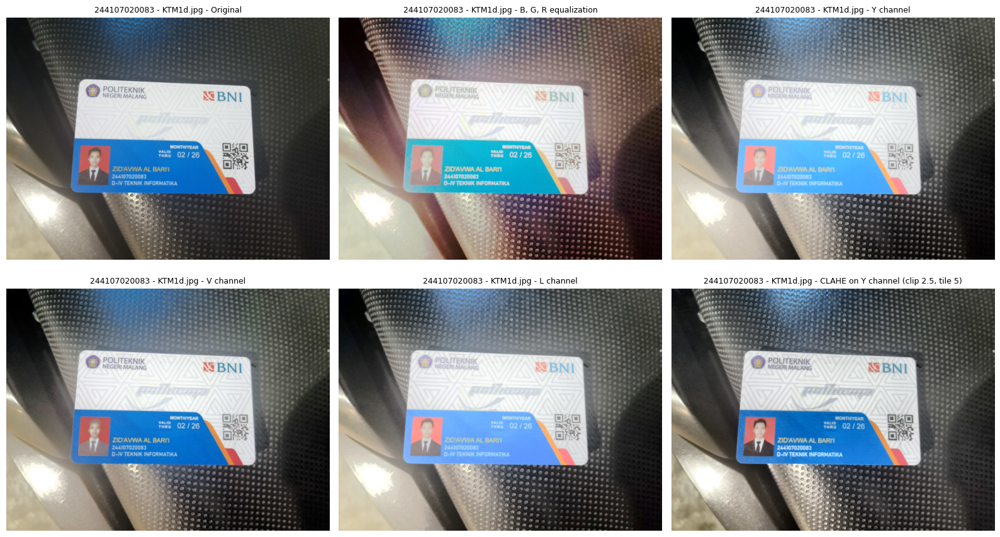

                  Equalization method Mean Hue shift (degrees)  Mean brightness after
                             Original                        -                   96.3
                 B, G, R equalization                    44.19                  128.5
                            Y channel                     0.29                  128.3
                            V channel                     2.93                  113.5
                            L channel                     7.52                  122.9
CLAHE on Y channel (clip 2.5, tile 5)                     0.01                  107.8


In [17]:
ktm1d = read_image(BASE + '/KTM1d.jpg')
df_ktm = analyze_equalization(ktm1d, 'KTM1d.jpg')
print(df_ktm.drop(columns='Visual observation notes').to_string(index=False))

**Results table (KTM1d.jpg)**

| Equalization method | Mean Hue shift (degrees) | Mean brightness after | Visual observation notes |
|---|---|---|---|
| Original image | - | 96.3 | |
| B, G, R channel equalization | 44.19 | 128.5 | |
| Y channel (YCrCb) | 0.29 | 128.3 | |
| V channel (HSV) | 2.93 | 113.5 | |
| L channel (LAB) | 7.52 | 122.9 | |
| CLAHE on Y channel (clip 2.5, tile 5) | 0.01 | 107.8 | |

**Answer**

1. The largest Hue shift occurs with separate B, G, R equalization, namely **44.19°** on KTM1d (53.03° on lena). Each channel is mapped with a different curve, so the R:G:B ratio also changes and the color shifts. The value is much larger than with the brightness-channel methods.
2. The shift is not exactly zero because the equalized brightness channel has to be converted back to BGR. In that step the values are rounded to integers 0-255 and out-of-range values are cut off (*clipping*). Rounding and clipping slightly change the B:G:R ratio, and Hue is computed from that ratio. Dark or pale pixels (low saturation) are very sensitive, because a difference of 1 level in one channel can shift Hue quite far. The L channel shifts the most of the three (7.52°), because in LAB many combinations of (new L, old a, b) fall outside the BGR color range, so more values get clipped.
3. The **Y** channel is the most suitable for KTM photos. Its Hue shift is the smallest (0.29°) and brightness rises from 96.3 to 128.3. The V channel shifts 2.93° and its brightness only rises to 113.5, because V is the maximum of R, G, B, not the brightness perceived by the eye. The L channel shifts 7.52°, so the card colors (e.g. the logo or colored areas) change most easily. Basis of assessment: *(state which part of the card you compared, e.g. the logo color or card background color that changes in the L or V result compared to Y)*.
4. CLAHE on the Y channel (clip 2.5, tile 5) compared with ordinary equalization on the Y channel, for KTM1d:
   - **Hue:** 0.01° vs 0.29°. CLAHE shifts colors less because the change per pixel is limited by clipLimit.
   - **Brightness:** 107.8 vs 128.3. CLAHE raises brightness more moderately (from 96.3), while ordinary equalization spreads the histogram over the whole range so the mean approaches 128.
   - **On lena** the results are almost the same: Hue 0.5° vs 0.4° and brightness 129.4 vs 127.9, because the image is not very dark.
   - **Conclusion:** CLAHE is gentler and preserves color better, while ordinary equalization is more aggressive in brightening.

**Part 8 - E-2 Question 1 (global equalization of KTM1a + PSNR)**

---

Max difference manual vs cv.equalizeHist : 1


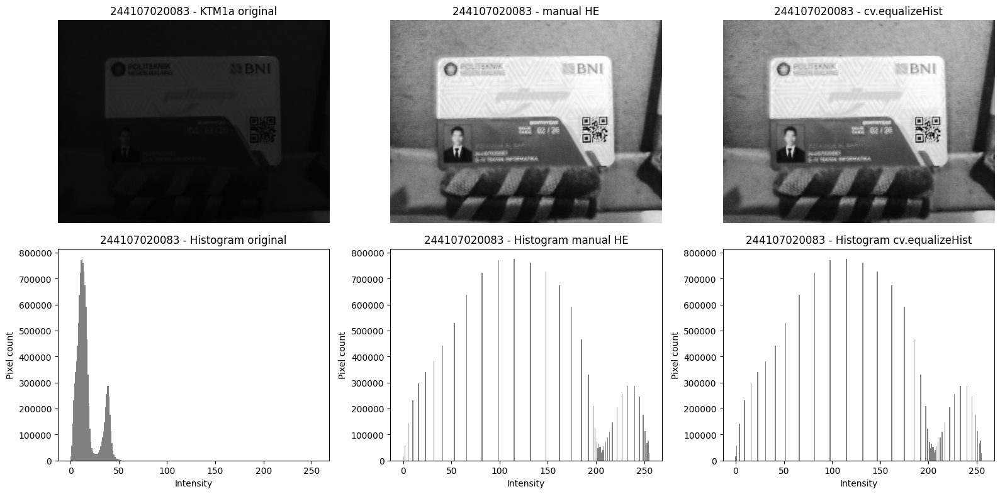

PSNR original vs manual HE         : 5.73 dB
PSNR original vs cv.equalizeHist   : 5.74 dB
Mean brightness original -> HE    : 16.7 -> 132.8
Standard deviation (contrast) original -> HE : 11.3 -> 72.6


In [18]:
g1a = read_image(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

he_g_manual = he_manual(g1a)
he_g_cv     = cv.equalizeHist(g1a)
print('Max difference manual vs cv.equalizeHist :', np.abs(he_g_manual.astype(int) - he_g_cv.astype(int)).max())

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
axs[0, 0].imshow(g1a, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title(make_title('KTM1a original'))
axs[0, 1].imshow(he_g_manual, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title(make_title('manual HE'))
axs[0, 2].imshow(he_g_cv, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title(make_title('cv.equalizeHist'))
for ax in axs[0]:
    ax.axis('off')

for ax, im, t in zip(axs[1], [g1a, he_g_manual, he_g_cv], ['original', 'manual HE', 'cv.equalizeHist']):
    ax.bar(np.arange(256), np.bincount(im.ravel(), minlength=256), color='gray', width=1.0)
    ax.set_title(make_title('Histogram ' + t))
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Pixel count')
plt.tight_layout()
plt.show()

psnr_manual = calculate_psnr(g1a, he_g_manual)
psnr_cv     = calculate_psnr(g1a, he_g_cv)
print('PSNR original vs manual HE         : %.2f dB' % psnr_manual)
print('PSNR original vs cv.equalizeHist   : %.2f dB' % psnr_cv)
print('Mean brightness original -> HE    : %.1f -> %.1f' % (g1a.mean(), he_g_manual.mean()))
print('Standard deviation (contrast) original -> HE : %.1f -> %.1f' % (g1a.std(), he_g_manual.std()))

**Answer E2-1**

- **Equalization result:** the KTM1a image, which was almost black at first, becomes clear. The card, BNI logo, photo, text, and QR code are visible, as is the background behind the card. The histogram, which was piled up at 0-50 (peaks around 12 and 38), is spread over the whole 0-255 range. The mean rises from 16.7 to 132.8 and the standard deviation (contrast) rises from 11.3 to 72.6, about 6 times higher.
- **The resulting histogram is sparse (comb-shaped), not flat.** The original image uses only about 50 intensity levels, so equalization only moves those levels to new positions that are far apart from each other. The levels in between are empty. This agrees with the module's note that equalization of a digital image never yields a truly flat histogram.
- **Manual vs `cv.equalizeHist`:** the maximum difference is 1 level and the PSNR is almost the same (5.73 vs 5.74 dB). The cause is the difference in the formula regarding `cdf_min` (see the step 2 answer), and it is not visible to the eye.
- **Why PSNR drops even though the image is clearer:** PSNR only measures the difference in pixel values against the original image. A PSNR of 5.73 dB is equivalent to an MSE of about 17,400 (average error of about 132 levels). The change in mean brightness alone (16.7 to 132.8, a difference of about 116 levels) already accounts for about three quarters of that MSE. Equalization deliberately changes pixel values as much as possible to raise contrast, so PSNR is bound to be low even though the image is more readable.
- **Conclusion:** PSNR is suitable for measuring fidelity (e.g. compression or denoising against a reference), but it is **not appropriate** for judging readability. In this case PSNR rates the result as "bad", even though the text and card actually become readable. Readability is better judged by local contrast in the text area or by visual inspection. Note also that equalization emphasizes noise and background texture, which is visible in the result.

**Part 9 - E-2 Question 2 (CLAHE on KTM1a)**

---

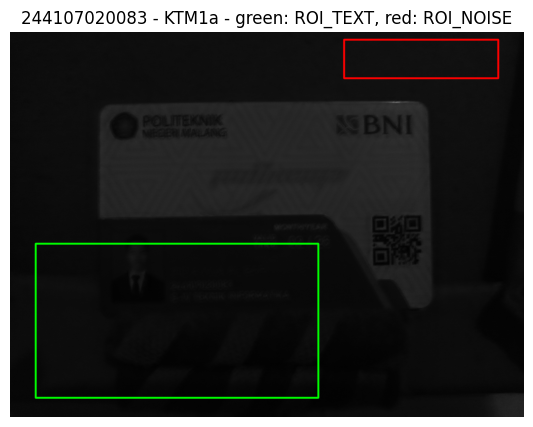

In [19]:
ROI_TEXT  = (0.55, 0.95, 0.05, 0.60)
ROI_NOISE = (0.02, 0.12, 0.65, 0.95)

def crop(img, roi):
    h, w = img.shape[:2]
    y0, y1, x0, x1 = roi
    return img[int(y0 * h):int(y1 * h), int(x0 * w):int(x1 * w)]

def draw_boxes(img_gray):
    rgb = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)
    h, w = img_gray.shape
    for roi, color in [(ROI_TEXT, (0, 255, 0)), (ROI_NOISE, (255, 0, 0))]:
        y0, y1, x0, x1 = roi
        cv.rectangle(rgb, (int(x0 * w), int(y0 * h)), (int(x1 * w), int(y1 * h)), color, max(2, w // 300))
    return rgb

plt.figure(figsize=(8, 5))
plt.imshow(draw_boxes(g1a))
plt.title(make_title('KTM1a - green: ROI_TEXT, red: ROI_NOISE'))
plt.axis('off')
plt.show()

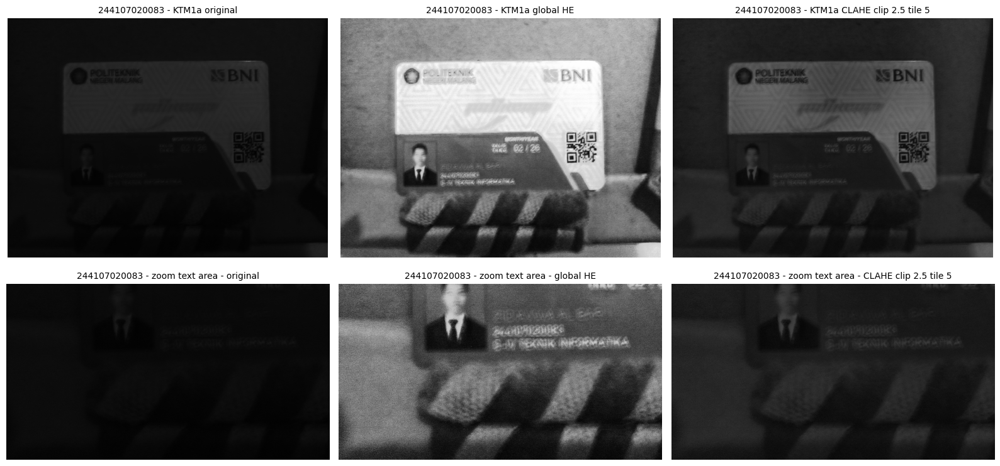

original                     | text area standard deviation:   3.9 | mean:   9.6 | PSNR vs original: -
global HE                    | text area standard deviation:  50.4 | mean:  81.4 | PSNR vs original: 5.74 dB
CLAHE clip 2.5 tile 5        | text area standard deviation:  11.9 | mean:  29.4 | PSNR vs original: 18.99 dB


In [20]:
def clahe_gray(g, clip, tile):
    return cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(g)

cl_g = clahe_gray(g1a, PARAM['clip'], PARAM['tile'])

three = [('original', g1a), ('global HE', he_g_cv), ('CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']), cl_g)]
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for j, (t, im) in enumerate(three):
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
    axs[0, j].set_title(make_title('KTM1a ' + t), fontsize=10)
    axs[0, j].axis('off')
    axs[1, j].imshow(crop(im, ROI_TEXT), cmap='gray', vmin=0, vmax=255)
    axs[1, j].set_title(make_title('zoom text area - ' + t), fontsize=10)
    axs[1, j].axis('off')
plt.tight_layout()
plt.show()

for t, im in three:
    print('%-28s | text area standard deviation: %5.1f | mean: %5.1f | PSNR vs original: %s'
          % (t, crop(im, ROI_TEXT).std(), crop(im, ROI_TEXT).mean(),
             '-' if im is g1a else '%.2f dB' % calculate_psnr(g1a, im)))

**Answer E2-1a (E2-2a)**

Based on the numbers in the text area (student ID and name), **global HE** produces more readable text than CLAHE (clip 2.5, tile 5).

| Image | Text area standard deviation | Text area mean | PSNR vs original |
|---|---|---|---|
| Original | 3.9 | 9.6 | - |
| Global HE | 50.4 | 81.4 | 5.74 dB |
| CLAHE (clip 2.5, tile 5) | 11.9 | 29.4 | 18.99 dB |

- **Text area contrast:** in the original image there is almost no difference between the letters and their background (3.9). Global HE raises it about 13 times (50.4), while CLAHE raises it only about 3 times (11.9). The light-dark difference between the letters and the background is much larger with global HE, so the text is easier to distinguish.
- **Brightness:** the text area mean under CLAHE is only 29.4, so that area is still dark. Under global HE the mean is 81.4, already in a range that is comfortable to view.
i. This is not a sign that the text is more readable, as discussed in the answer to E2-1.
- **Conclusion:** for a very dark image like KTM1a, global HE is more readable in the student ID and name area. The advantage of CLAHE is that it does not emphasize noise as much in plain areas, and that is discussed in part 2b. *(Compare with the text area zoom images: make sure the letters under global HE really look clearer, not just brighter.)*

clipLimit values tried: [1.5, 2.0, 2.5, 3.0] (your value: 2.5 )


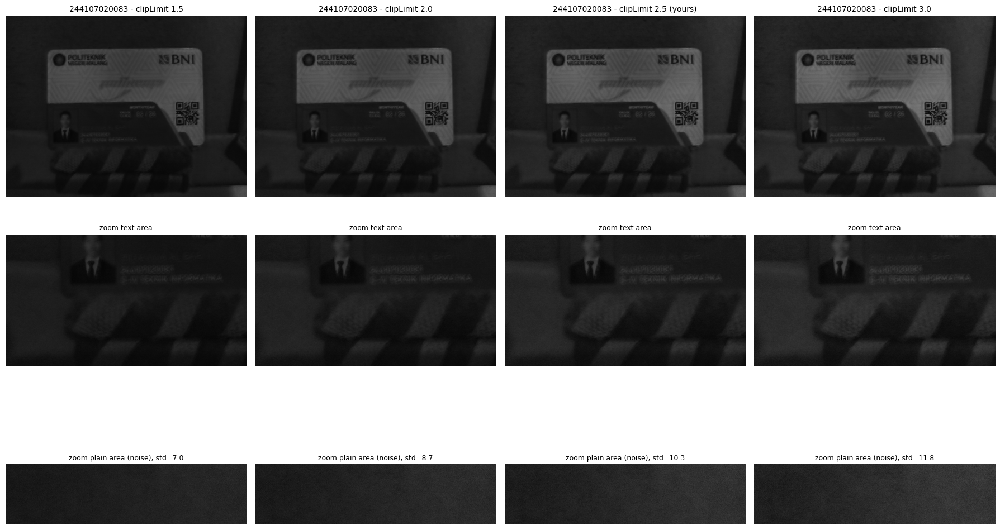

Original plain area (std): 2.3
 clipLimit  text area contrast (std)  plain area noise (std)  PSNR vs original (dB)
       1.5                       8.7                     7.0                  22.56
       2.0                      10.3                     8.7                  20.51
       2.5                      11.9                    10.3                  18.99
       3.0                      13.5                    11.8                  17.77


In [21]:
# (b) three other clipLimit values around PARAM['clip']
c0 = PARAM['clip']
candidates = sorted([c for c in [c0 - 1.0, c0 - 0.5, c0 + 0.5, c0 + 1.0, c0 + 1.5] if c >= 0.5],
                    key=lambda c: (abs(c - c0), c))[:3]
clip_list = sorted(candidates + [c0])
print('clipLimit values tried:', clip_list, '(your value:', c0, ')')

fig, axs = plt.subplots(3, len(clip_list), figsize=(4.5 * len(clip_list), 11))
summary = []
for j, c in enumerate(clip_list):
    im = clahe_gray(g1a, c, PARAM['tile'])
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
    axs[0, j].set_title(make_title('clipLimit %s%s' % (c, ' (yours)' if c == c0 else '')), fontsize=10)
    axs[1, j].imshow(crop(im, ROI_TEXT), cmap='gray', vmin=0, vmax=255)
    axs[1, j].set_title('zoom text area', fontsize=9)
    noise_roi = crop(im, ROI_NOISE)
    axs[2, j].imshow(noise_roi, cmap='gray', vmin=0, vmax=255)
    axs[2, j].set_title('zoom plain area (noise), std=%.1f' % noise_roi.std(), fontsize=9)
    for i in range(3):
        axs[i, j].axis('off')
    summary.append({'clipLimit': c,
                    'text area contrast (std)': round(float(crop(im, ROI_TEXT).std()), 1),
                    'plain area noise (std)': round(float(noise_roi.std()), 1),
                    'PSNR vs original (dB)': round(calculate_psnr(g1a, im), 2)})
plt.tight_layout()
plt.show()

print('Original plain area (std): %.1f' % crop(g1a, ROI_NOISE).std())
print(pd.DataFrame(summary).to_string(index=False))

**Answer E2-2b**

clipLimit values tried: 1.5; 2.0; 2.5 (your value); 3.0.

| clipLimit | Text area contrast (std) | Plain area noise (std) | PSNR vs original (dB) |
|---|---|---|---|
| Original | 3.9 | 2.3 | - |
| 1.5 | 8.7 | 7.0 | 22.56 |
| 2.0 | 10.3 | 8.7 | 20.51 |
| **2.5 (yours)** | **11.9** | **10.3** | **18.99** |
| 3.0 | 13.5 | 11.8 | 17.77 |

- **Trend:** text contrast rises about 1.6 for every 0.5 increase in clipLimit, and plain area noise rises by almost the same amount (about 1.5-1.7). So raising clipLimit adds text contrast and noise at the same time. PSNR keeps falling because the image moves further from the original.
- **Best value: 2.5.** Text contrast is already about 3 times the original image (11.9 vs 3.9), while noise is about 4.5 times (10.3 vs 2.3). At 1.5-2.0 the text still lacks contrast (8.7-10.3). At 3.0 contrast rises only 1.6 more while noise rises 1.5, so the added contrast is almost entirely consumed by noise. The ratio of text contrast to noise also falls slowly from 1.24 (clip 1.5) to 1.14 (clip 3.0).
- **Where the noise starts to stand out:** *(fill in from the third-row zoom image)* in `ROI_NOISE`, i.e. the plain area outside the text (the dark background around the card). The speckled texture in this area becomes clearer from clipLimit 2.5-3.0, as shown by the std rising from 2.3 (original) to 10.3 and 11.8. It is most likely sensor noise that was previously hidden in the dark and is now amplified as well.
- **Conclusion:** clipLimit 2.5 is enough to raise readability without letting noise become too dominant. However, the text contrast of CLAHE (maximum 13.5) remains far below global HE (50.4), consistent with the E2-2a result.

**Part 10 - E-3 Floyd-Steinberg Dithering**

---

In [22]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            old = img[y, x]
            new = np.round(old / step) * step
            img[y, x] = new
            error = old - new
            if x + 1 < W:                 img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:       img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                 img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:   img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_color(bgr, L=2):
    return cv.merge([floyd_steinberg(c, L) for c in cv.split(bgr)])

MAX_SIDE = 800
def downscale(img, max_side=MAX_SIDE):
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    if s >= 1:
        return img
    return cv.resize(img, (int(w * s), int(h * s)), interpolation=cv.INTER_AREA)

**Stage 1 - sample image (lena.jpg)**

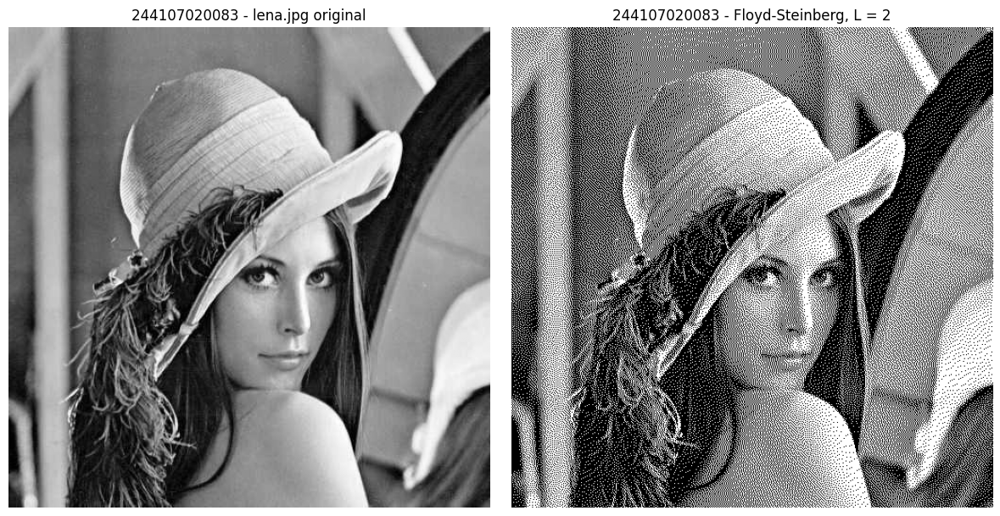

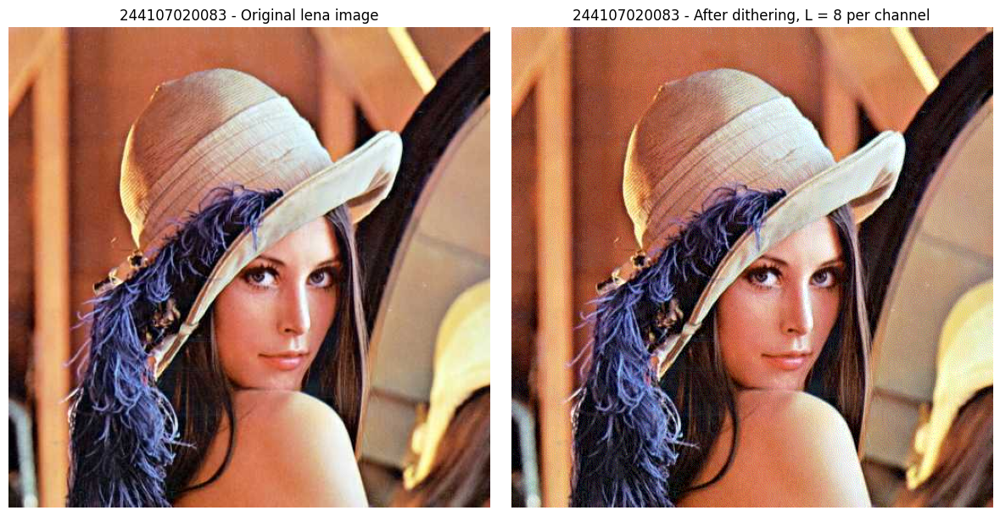

In [23]:
lena_gray = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)
lena_dither2 = floyd_steinberg(lena_gray, L=2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(lena_gray, cmap='gray', vmin=0, vmax=255)
axs[0].set_title(make_title('lena.jpg original'))
axs[1].imshow(lena_dither2, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(make_title('Floyd-Steinberg, L = 2'))
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

# color image with PARAM['L'] levels
lena_dither_c = floyd_steinberg_color(lena, L=PARAM['L'])
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(lena, cv.COLOR_BGR2RGB))
axs[0].set_title(make_title('Original lena image'))
axs[1].imshow(cv.cvtColor(lena_dither_c, cv.COLOR_BGR2RGB))
axs[1].set_title(make_title('After dithering, L = %d per channel' % PARAM['L']))
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Stage 2 - own image (KTM1b.jpg, L = PARAM['L'])**

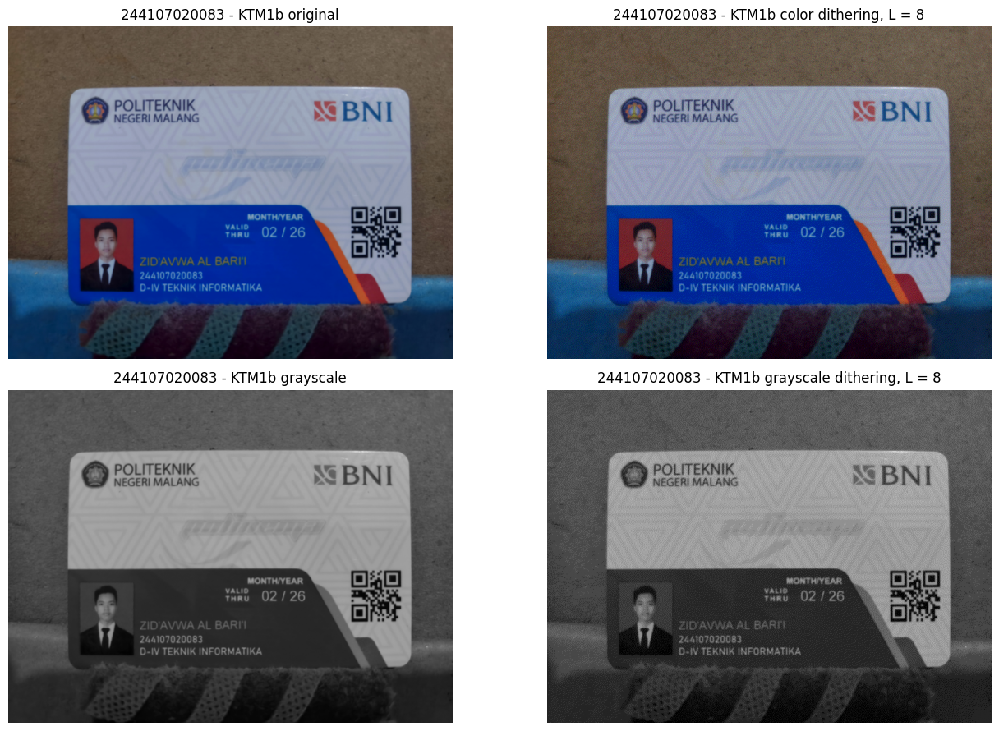

Number of unique values per channel after dithering: [8, 7, 7] (must be <= L = 8 )


In [24]:
ktm1b_s = downscale(ktm1b)
ktm1b_dither = floyd_steinberg_color(ktm1b_s, L=PARAM['L'])
ktm1b_gray = cv.cvtColor(ktm1b_s, cv.COLOR_BGR2GRAY)
ktm1b_gray_dither = floyd_steinberg(ktm1b_gray, L=PARAM['L'])

fig, axs = plt.subplots(2, 2, figsize=(14, 9))
axs[0, 0].imshow(cv.cvtColor(ktm1b_s, cv.COLOR_BGR2RGB))
axs[0, 0].set_title(make_title('KTM1b original'))
axs[0, 1].imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
axs[0, 1].set_title(make_title('KTM1b color dithering, L = %d' % PARAM['L']))
axs[1, 0].imshow(ktm1b_gray, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title(make_title('KTM1b grayscale'))
axs[1, 1].imshow(ktm1b_gray_dither, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title(make_title('KTM1b grayscale dithering, L = %d' % PARAM['L']))
for ax in axs.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Number of unique values per channel after dithering:', [len(np.unique(ktm1b_dither[:, :, i])) for i in range(3)], '(must be <= L =', PARAM['L'], ')')

**Part 11 - E-3 Task 2 (Equalization then Dithering)**

---

In [25]:
def order_results(gray, L):
    direct = floyd_steinberg(gray, L)
    he = cv.equalizeHist(gray)
    he_then_dither = floyd_steinberg(he, L)
    return direct, he, he_then_dither

def show_order(gray, name, L):
    direct, he, he_d = order_results(gray, L)
    fig, axs = plt.subplots(1, 4, figsize=(20, 5.5))
    for ax, im, t in zip(axs, [gray, direct, he, he_d],
                         [name + ' original', 'direct dithering', 'equalization result', 'equalization then dithering']):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(make_title(t), fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return direct, he_d

**Stage 1 - sample image (lena_lc.jpg, L = 2)**

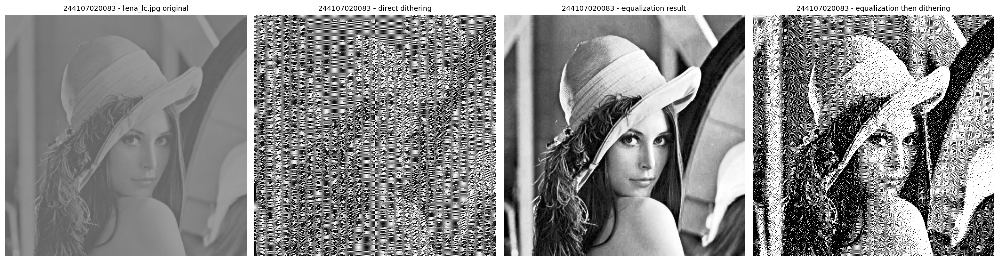

In [26]:
lena_lc_gray = cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY)
_ = show_order(lena_lc_gray, 'lena_lc.jpg', L=2)

**Stage 2 - own image (KTM1a.jpg, L = PARAM['L'])**

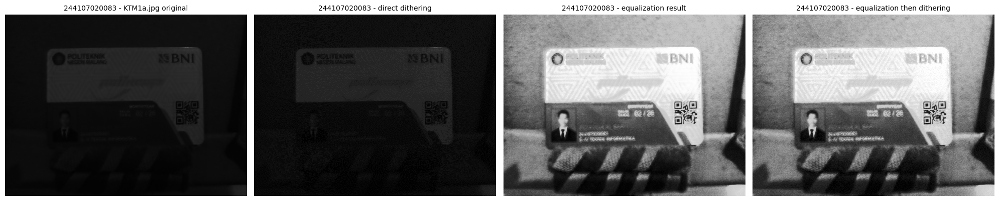

Text area contrast (after blur, larger = more readable):
  direct dithering              : 3.1
  equalization then dithering   : 43.6


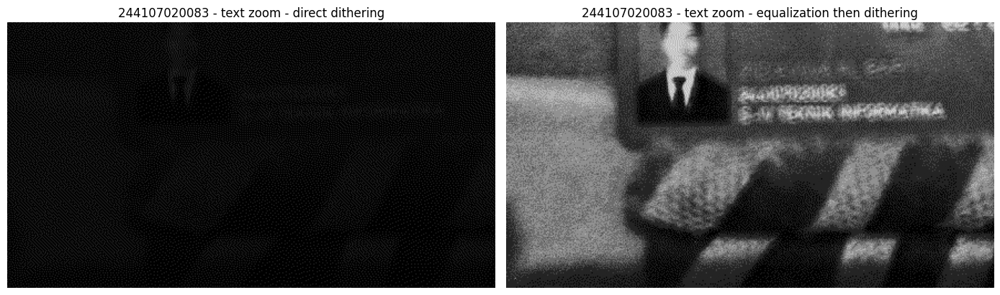

In [27]:
g1a_s = downscale(g1a)
direct, he_d = show_order(g1a_s, 'KTM1a.jpg', L=PARAM['L'])

# text area readability measure: the dithered image is blurred first to imitate viewing from a normal distance,
# then its local contrast (standard deviation) is measured in the student ID and name area.
def text_contrast(im):
    blurred = cv.GaussianBlur(im, (0, 0), sigmaX=2)
    return crop(blurred, ROI_TEXT).std()

print('Text area contrast (after blur, larger = more readable):')
print('  direct dithering              : %.1f' % text_contrast(direct))
print('  equalization then dithering   : %.1f' % text_contrast(he_d))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].imshow(crop(direct, ROI_TEXT), cmap='gray', vmin=0, vmax=255)
axs[0].set_title(make_title('text zoom - direct dithering'))
axs[1].imshow(crop(he_d, ROI_TEXT), cmap='gray', vmin=0, vmax=255)
axs[1].set_title(make_title('text zoom - equalization then dithering'))
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()